In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [83]:
from PIL import Image

import math
import copy
import itertools
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(["science", "notebook"])

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from torchvision.datasets import FashionMNIST
from torchvision.utils import make_grid, save_image
import pytorch_lightning as pl

torch.set_float32_matmul_precision('high')
seed = pl.seed_everything(42)

Seed set to 42


# HW 2

#### Juntang Wang (jw853)

## Problem 1. backpropagation

---

| layer | activation dimensions | weights | bias |
|-------|----------------------|---------|------|
| input | 128 × 128 × 3 | 0 | 0 |
| conv1 | 120 × 120 × 32 | 7 776 | 32 |
| pool1 | 60 × 60 × 32 | 0 | 0 |
| conv2 | 56 × 56 × 64 | 51 200 | 64 |
| pool2 | 28 × 28 × 64 | 0 | 0 |
| conv3 | 24 × 24 × 64 | 102 400 | 64 |
| pool3 | 12 × 12 × 64 | 0 | 0 |
| flatten | – (12 × 12 × 64 = 9 216) | – | – |
| FC | 10 | 92 160 | 10 |

⸻

##### Derivation / Reasoning

Below, $H$ and $W$ are the input height and width for a layer, $K$ is the kernel size, $S$ the stride, and $P$ the (zero) padding.
The spatial output size for a convolution or pooling layer with no padding is

$$H_{\text{out}} = \Bigl\lfloor\frac{H - K}{S}\Bigr\rfloor + 1,\qquad
W_{\text{out}} = \Bigl\lfloor\frac{W - K}{S}\Bigr\rfloor + 1.$$

1. conv1
   - Input: $128 \times 128 \times 3$
   - $K=9,\;S=1 \rightarrow 120 \times 120$
   - Filters = $32 \Rightarrow$ activation $120 \times 120 \times 32$
   - Weights = $32 \times 9 \times 9 \times 3 = 7,776$
   - Bias = $32$

2. pool1
   - $K=2,\;S=2$ halves each spatial dimension: $60 \times 60 \times 32$
   - No parameters

3. conv2
   - Input: $60 \times 60 \times 32$
   - $K=5,\;S=1 \rightarrow 56 \times 56$
   - Filters = $64 \Rightarrow$ activation $56 \times 56 \times 64$
   - Weights = $64 \times 5 \times 5 \times 32 = 51,200$
   - Bias = $64$

4. pool2
   - $K=2,\;S=2 \rightarrow 28 \times 28 \times 64$
   - No parameters

5. conv3
   - Input: $28 \times 28 \times 64$
   - $K=5,\;S=1 \rightarrow 24 \times 24$
   - Filters = $64 \Rightarrow$ activation $24 \times 24 \times 64$
   - Weights = $64 \times 5 \times 5 \times 64 = 102,400$
   - Bias = $64$

6. pool3
   - $K=2,\;S=2 \rightarrow 12 \times 12 \times 64$

7. flatten
   - Total features = $12 \times 12 \times 64 = 9,216$

8. Fully-connected (FC)
   - Inputs = $9,216$, outputs = $10$
   - Weights = $9,216 \times 10 = 92,160$
   - Bias = $10$

All calculations respect the stated setup: 0-padding, stride 1 in convolutions, stride 2 in all $2 \times 2$ max-pooling layers, and the specified filter counts and kernel sizes.



## Problem 2. RNN

---

#### 1.  What does $f^{100}(x)=\underbrace{f\!\circ\;f\!\circ\dots\circ f}_{100\text{ times}}(x)$ look like?

##### a.  Locate the fixed-points of f

From Figure 1 the black curve $f(x)$ crosses the diagonal $y=x$ five times at points a, b, c, d, e:

| fixed-point | slope $f^{\prime}(x^*)$ | stability |
|-------------|--------------------------|-----------|
| a | $0<f^{\prime}(a)<1$ (shallow) | attractor |
| b | $f^{\prime}(b)>1$ (steep) | repellor |
| c | $0<f^{\prime}(c)<1$ (shallow) | attractor |
| d | $f^{\prime}(d)>1$ (steep) | repellor |
| e | $0<f^{\prime}(e)<1$ (shallow) | attractor |

Because $f$ is monotone increasing, no other intersections exist on $[0,1]$ (the Intermediate Value Theorem plus monotonicity).

##### b.  Iterate the map

For a one-dimensional iterated map the long–term behaviour is governed by those fixed-points:
- If $x_0\in(0,b)$ the sequence $x_{t+1}=f(x_t)$ converges geometrically to the attractor a.
- If $x_0\in(b,d)$ it converges to the attractor c.
- If $x_0\in(d,1)$ it converges to the attractor e.
- The initial conditions $x_0=b$ and $x_0=d$ remain at these unstable points.

After 100 compositions the transients are completely gone, so $f^{100}(x)$ is essentially a step function:

$f^{100}(x)\;=\;
\begin{cases}
a & 0\le x < b\\[2pt]
b & x = b\\[2pt]
c & b < x < d\\[2pt]
d & x = d\\[2pt]
e & d < x \le 1
\end{cases}$

##### c.  Why is this asked in the RNN section?

A vanilla RNN performs
$h_t = f_\theta(h_{t-1},x_t)$.
If you unroll the network for $T$ steps and keep the input fixed (or think of $x_t=0$), the hidden state is the $T$-fold composition of the same nonlinear map—exactly the situation in this exercise. The figure highlights two phenomena that matter for RNN training:
- Attractor dynamics / saturation – repeated composition drives the state into a small set of fixed-points; once there, the network "forgets" earlier inputs.
- Vanishing & exploding gradients – the same product of Jacobians that pushes the state toward (or away from) a fixed-point simultaneously damps (or blows up) back-propagated gradients.

Thus the sketch is a 1-D caricature of what goes wrong in deep-time RNNs and why architectures such as LSTMs/Gated-RNNs were invented.


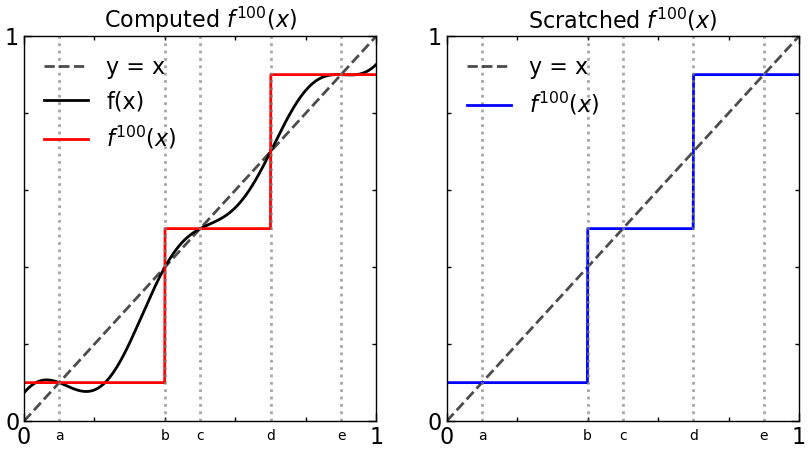

In [60]:
axes = plt.subplots(1, 2, figsize=(10, 5))[1].flatten()
cpts = {"a": 0.1, "b": 0.4, "c": 0.5, "d": 0.7, "e": 0.9} # crossing points
x = np.linspace(0, 1, 1000)
# ---------------------------------------------------------------------------- #
#                                  Solution 1                                  #
# ---------------------------------------------------------------------------- #
def f(x):
    result, to_sub = x, 1
    for point in cpts.values():
        to_sub *= np.sin(np.pi * (x - point))
    return result - to_sub

y_f = f(x)
y_f100 = x.copy()
for _ in range(100): y_f100 = f(y_f100)

ax = axes[0]
ax.plot(x, x, 'k--', alpha=0.7, label='y = x')
ax.plot(x, y_f, 'k', label='f(x)')
ax.plot(x, y_f100, 'r-', label='$f^{100}(x)$')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
for label, point in cpts.items():
    ax.axvline(x=point, color='gray', linestyle=':', alpha=0.7)
    ax.text(point, -0.02, label, ha='center', va='top', 
            transform=ax.get_xaxis_transform())
ax.set_title('Computed $f^{100}(x)$')
ax.legend()
# ---------------------------------------------------------------------------- #
#                                  Solution 2                                  #
# ---------------------------------------------------------------------------- #
def scatched_f100(x): # cases for b and d neglected as no dif for visual
    if x < cpts["b"]:
        return cpts["a"]
    elif x < cpts["d"]:
        return cpts["c"]
    else:
        return cpts["e"]

sy_f100 = np.array([scatched_f100(x) for x in x])

ax = axes[1]
ax.plot(x, x, 'k--', alpha=0.7, label='y = x')
ax.plot(x, sy_f100, 'b-', label='$f^{100}(x)$')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
for label, point in cpts.items():
    ax.axvline(x=point, color='gray', linestyle=':', alpha=0.7)
    ax.text(point, -0.02, label, ha='center', va='top', 
            transform=ax.get_xaxis_transform())
ax.set_title('Scratched $f^{100}(x)$')
ax.legend()
plt.show()


#### 2.  Back-propagation-through-time (BPTT) — gradient w.r.t. $U$

Below is the same BPTT derivation written in exactly the symbols you copied from the lecture slides.

\begin{aligned}
a^{(t)} &= b + W\,h^{(t-1)} + U\,x^{(t)},\\
h^{(t)} &= \tanh\!\bigl(a^{(t)}\bigr),\\
o^{(t)} &= c + V\,h^{(t)},\\
\hat y^{(t)} &= \operatorname{softmax}\!\bigl(o^{(t)}\bigr),\\[4pt]
L &= \sum_{t} L^{(t)} = -\sum_{t} \log p_{\text{model}}\!\bigl(y^{(t)}\mid x^{(1)},\dots,x^{(t)}\bigr).
\end{aligned}

Our goal is $\displaystyle \nabla_{U}L$.

Define the one-hot ground-truth vector $\hat y^{(t)}$ and

$$
e^{(t)}\;=\;\frac{\partial L^{(t)}}{\partial o^{(t)}} \;=\; \hat y^{(t)}-y^{(t)}. \tag{1}
$$

⸻

##### 1.  Error signal at the hidden state

Let
$$\delta_h^{(t)} \;=\;\frac{\partial L}{\partial h^{(t)}}\in\mathbb{R}^{H}.$$

Because $h^{(t)}$ influences its own time-step through $o^{(t)}$ and all future time-steps through the recurrent connection $W$,

$$
\boxed{\;
\delta_h^{(t)} \;=\; V^{\!\top} e^{(t)} \;+\; W^{\!\top}\,\delta_a^{(t+1)}
\;} \tag{2}
$$

where $\delta_a^{(t)}$ is the error at the pre-activation $a^{(t)}$ (defined next).
The recursion is initialized with $\delta_a^{(T+1)}=0$.

---

##### 2.  Error signal at the pre-activation

Because $h^{(t)}=\tanh a^{(t)}$,

$$\frac{\partial h^{(t)}}{\partial a^{(t)}} = \operatorname{diag}\!\bigl(1-h^{(t)}\odot h^{(t)}\bigr),$$

so the element-wise error entering $a^{(t)}$ is

$$
\boxed{\;
\delta_a^{(t)} \;=\; \delta_h^{(t)} \;\odot\; \bigl(1-h^{(t)}\odot h^{(t)}\bigr)
\;} \tag{3}
$$

($\odot = $ Hadamard/element-wise product).

---

##### 3.  Gradient with respect to $U$

Only $a^{(t)}$ depends directly on $U$:

$$a^{(t)} = \bigl[\dots\bigr] + U\,x^{(t)}.$$

Therefore

$$
\frac{\partial L}{\partial U}
= \sum_{t=1}^{T}
\frac{\partial L}{\partial a^{(t)}}\,
\frac{\partial a^{(t)}}{\partial U}
= \sum_{t=1}^{T}
\delta_a^{(t)} \, (x^{(t)})^{\!\top}. \tag{4}
$$

Combining (2)–(4) yields the BPTT recursion:

$$
\boxed{
\begin{aligned}
\text{(i)}\;& e^{(t)}          &=&\; \hat y^{(t)}-y^{(t)}\\[2pt]
\text{(ii)}\;& \delta_h^{(t)}  &=&\; V^{\!\top} e^{(t)} + W^{\!\top}\,\delta_a^{(t+1)}\\[2pt]
\text{(iii)}\;& \delta_a^{(t)} &=&\; \delta_h^{(t)}\odot\bigl(1-h^{(t)}\odot h^{(t)}\bigr)\\[2pt]
\text{(iv)}\;& \nabla_U L      &=&\; \sum_{t=1}^{T} \delta_a^{(t)} (x^{(t)})^{\!\top}.
\end{aligned}}
$$

Algorithmically you iterate backwards from $t=T$ to $1$:
1. Compute $e^{(t)}$.
2. Propagate $\delta_h^{(t)}$ via (ii).
3. Map to $\delta_a^{(t)}$ via (iii).
4. Accumulate $\nabla_U L$ with (iv).

## Problem 3. 

---

Fix two points $y_{1},y_{2}\in\mathbb{R}^{d}$ and let $\varepsilon>0$.
Pick $x_{\varepsilon}$ such that

$\phi^{c}(y_{1})\;>\;\lVert x_{\varepsilon}-y_{1}\rVert-\phi(x_{\varepsilon})-\varepsilon$.

Because the same $x_{\varepsilon}$ is admissible in the infimum that defines $\phi^{c}(y_{2})$,

$\phi^{c}(y_{2})\;\le\;\lVert x_{\varepsilon}-y_{2}\rVert-\phi(x_{\varepsilon})$.

Subtracting the two lines gives

$\phi^{c}(y_{1})-\phi^{c}(y_{2})
\;>\;\lVert x_{\varepsilon}-y_{1}\rVert-\lVert x_{\varepsilon}-y_{2}\rVert-\varepsilon$.

By the triangle inequality
$\lVert x_{\varepsilon}-y_{1}\rVert-\lVert x_{\varepsilon}-y_{2}\rVert\ge -\lVert y_{1}-y_{2}\rVert$,
whence

$\phi^{c}(y_{1})-\phi^{c}(y_{2})\;>\;-\lVert y_{1}-y_{2}\rVert-\varepsilon$.

Letting $\varepsilon\downarrow 0$ we obtain the one–sided estimate

$\phi^{c}(y_{1})-\phi^{c}(y_{2})\;\ge\;-\lVert y_{1}-y_{2}\rVert$.

Exchanging $y_{1}$ and $y_{2}$ yields the opposite inequality, so altogether

$\boxed{\;|\phi^{c}(y_{1})-\phi^{c}(y_{2})|\le\lVert y_{1}-y_{2}\rVert\;}$,
$\qquad\forall\,y_{1},y_{2}\in\mathbb{R}^{d}$.

Hence $\lVert\phi^{c}\rVert_{\mathrm{Lip}}\le 1$

## Problem 4. 

---

1. Lipschitz bound in any direction.
    Let $v\in\mathbb{R}^{d}$ with $\lVert v\rVert_2=1$.

    For $t\in\mathbb{R}$ we have, by the Lipschitz condition,

    $|f(x+tv)-f(x)| \;\le\; |t|\,\lVert v\rVert_2 \;=\; |t|$.

2. Take the derivative along v.
    Because $f$ is $C^1$, the directional derivative exists and equals the dot-product with the gradient:

    $\frac{d}{dt} f(x+tv)\Big|_{t=0}= \langle\nabla f(x),v\rangle$.

    Dividing the inequality in Step 1 by $|t|$ and letting $t\to0$ gives

    $|\langle\nabla f(x),v\rangle|\;\le\;1\qquad\text{for every unit }v$.

3. Maximising over all directions.
    The Euclidean norm of a vector is the maximum absolute inner product with unit vectors:

    $\lVert\nabla f(x)\rVert_2 = \sup_{\lVert v\rVert_2=1} |\langle\nabla f(x),v\rangle|$.

    Hence $\lVert\nabla f(x)\rVert_2\le 1$.

## Problem 5. 

---

In [3]:
# ----------------------
# Hyperparameters
# ----------------------
BATCH_SIZE = 128
IMAGE_SIZE = 28
NZ = 128        # latent dimension
LR = 2e-4
BETAS = (0.5, 0.999)
N_CRITIC = 5
CLIP = 0.01
MAX_EPOCHS = 30

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1 or classname.find('Linear') != -1:
        nn.init.normal_(m.weight, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.constant_(m.bias, 0)

In [4]:
# ----------------------
# DataModule
# ----------------------
class FMData(pl.LightningDataModule):
    def __init__(self, data_dir='./data'):
        super().__init__()
        self.data_dir = data_dir
        self.transform = transforms.Compose([
            transforms.Resize(IMAGE_SIZE),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def prepare_data(self):
        FashionMNIST(self.data_dir, train=True, download=True)
        FashionMNIST(self.data_dir, train=False, download=True)

    def setup(self, stage=None):
        self.train = FashionMNIST(self.data_dir, train=True, transform=self.transform)

    def train_dataloader(self):
        return DataLoader(self.train, batch_size=BATCH_SIZE, shuffle=True, num_workers=12, persistent_workers=True)


In [5]:
# ----------------------
# Models
# ----------------------
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        ngf = 128
        self.net = nn.Sequential(
            nn.Linear(NZ, 7 * 7 * ngf),
            nn.LeakyReLU(0.233),
            nn.Unflatten(1, (ngf, 7, 7)),
            nn.ConvTranspose2d(ngf, ngf, 4, 2, padding=1),
            nn.BatchNorm2d(ngf), nn.LeakyReLU(0.233),
            nn.ConvTranspose2d(ngf, ngf, 4, 2, padding=1),
            nn.BatchNorm2d(ngf), nn.LeakyReLU(0.233),
            nn.Conv2d(ngf, 1, 7, 1, padding=3),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        ndf = 32
        self.net = nn.Sequential(
            nn.Conv2d(1, ndf, 3, 2, padding=1),
            nn.LeakyReLU(0.233),
            nn.Conv2d(ndf, ndf*2, 3, 1, padding=1),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.233),
            nn.Conv2d(ndf*2, ndf*4, 3, 2, padding=1),
            nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.233),
            nn.Conv2d(ndf*4, ndf*8, 3, 1, padding=1),
            nn.BatchNorm2d(ndf*8), nn.LeakyReLU(0.233),
            nn.AdaptiveMaxPool2d(1),
            nn.Flatten(),
            nn.Linear(ndf*8, 1),
            # nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze()

In [6]:

# ----------------------
# LightningModule
# ----------------------
class GAN(pl.LightningModule):
    def __init__(self, gan_type, sample_dir):
        super().__init__()
        self.gan_type = gan_type
        self.G = Generator()
        self.D = Discriminator()
        self.n_critic = N_CRITIC
        self.clip = CLIP
        self.sample_dir = sample_dir
        self.automatic_optimization = False
        self.fixed_z = torch.randn(7, NZ)
        if gan_type == 'dcgan':
            self.crit = nn.BCEWithLogitsLoss() # nn.BCEWithLogitsLoss()
        elif gan_type == 'fgan':
            self.crit = nn.MSELoss()
        self.save_hyperparameters()
        self.G.apply(weights_init)
        self.D.apply(weights_init)

    def forward(self, z):
        return self.G(z)

    def configure_optimizers(self):
        opt_d = optim.Adam(self.D.parameters(), lr=LR, betas=BETAS)
        opt_g = optim.Adam(self.G.parameters(), lr=LR, betas=BETAS)
        return [opt_d, opt_g]

    def training_step(self, batch, batch_idx):
        imgs, _ = batch
        opt_d, opt_g = self.optimizers()
        b = imgs.size(0)
        dev = imgs.device
        
        # Train discriminator
        self._train_discriminator(imgs, b, dev, opt_d)
        
        # Train generator
        self._train_generator(b, dev, opt_g)
        
    def _train_discriminator(self, imgs, b, dev, opt_d):
        if self.gan_type == 'dcgan':
            d_real = self.D(imgs)
            z = torch.randn(b, NZ, device=dev)
            fake_imgs = self.G(z)
            d_fake = self.D(fake_imgs.detach())
            l_real = torch.ones(b, device=dev)
            l_fake = torch.zeros(b, device=dev)
            # labels += 0.05 * torch.randn(labels.size(), device=dev)  # Label smoothing
            loss_d = self.crit(d_real, l_real) + self.crit(d_fake, l_fake)
            
        elif self.gan_type == 'wgan':
            for _ in range(self.n_critic):
                d_real = self.D(imgs)
                z = torch.randn(b, NZ, device=dev)
                fake_imgs = self.G(z)
                d_fake = self.D(fake_imgs.detach())
                loss_d = -torch.mean(d_real) + torch.mean(d_fake)
                
                opt_d.zero_grad()
                self.manual_backward(loss_d)
                opt_d.step()
                
                # Clip weights
                for p in self.D.parameters():
                    p.data.clamp_(-self.clip, self.clip)
            return  # Already optimized in the loop
            
        elif self.gan_type == 'fgan':
            d_real = self.D(imgs)
            z = torch.randn(b, NZ, device=dev)
            fake_imgs = self.G(z)
            d_fake = self.D(fake_imgs.detach())
            l_real = torch.ones(b, device=dev)
            l_fake = torch.zeros(b, device=dev)
            
            # MSE on real vs 1, fake vs 0
            loss_d = 0.5 * self.crit(d_real, l_real) \
                   + 0.5 * self.crit(d_fake, l_fake)
        
        opt_d.zero_grad()
        self.manual_backward(loss_d)
        opt_d.step()
        self.log('loss_d', loss_d, prog_bar=True)
        
    def _train_generator(self, b, dev, opt_g):
        z = torch.randn(b, NZ, device=dev)
        
        if self.gan_type == 'dcgan':
            ms_labels = torch.ones(b, device=dev)  # Misleading labels
            pred = self.D(self.G(z))
            loss_g = self.crit(pred, ms_labels)
            
        elif self.gan_type == 'wgan':
            fake_imgs = self.G(z)
            d_fake = self.D(fake_imgs)
            loss_g = -torch.mean(d_fake)
            
        elif self.gan_type == 'fgan':
            ms_labels = torch.ones(b, device=dev)  # Misleading labels
            fake_imgs = self.G(z)
            d_fake = self.D(fake_imgs)
            loss_g = 0.5 * self.crit(d_fake, ms_labels)
        
        opt_g.zero_grad()
        self.manual_backward(loss_g)
        opt_g.step()
        self.log('loss_g', loss_g, prog_bar=True)

    def on_train_epoch_end(self):
        dev = self.device
        imgs = self.G(self.fixed_z.to(dev))
        grid = make_grid(imgs, normalize=True)
        save_image(grid, f"{self.sample_dir}/epoch{self.current_epoch}.png")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type              | Params | Mode 
---------------------------------------------------
0 | G    | Generator         | 1.3 M  | train
1 | D    | Discriminator     | 388 K  | train
2 | crit | BCEWithLogitsLoss | 0      | train
---------------------------------------------------
1.7 M     Trainable params
0         Non-trainable params
1.7 M     Total params
6.918     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


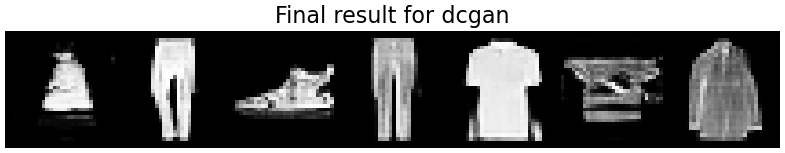

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type          | Params | Mode 
-----------------------------------------------
0 | G    | Generator     | 1.3 M  | train
1 | D    | Discriminator | 388 K  | train
-----------------------------------------------
1.7 M     Trainable params
0         Non-trainable params
1.7 M     Total params
6.918     Total estimated model params size (MB)
29        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


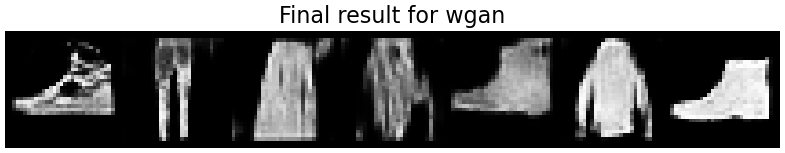

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type          | Params | Mode 
-----------------------------------------------
0 | G    | Generator     | 1.3 M  | train
1 | D    | Discriminator | 388 K  | train
2 | crit | MSELoss       | 0      | train
-----------------------------------------------
1.7 M     Trainable params
0         Non-trainable params
1.7 M     Total params
6.918     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


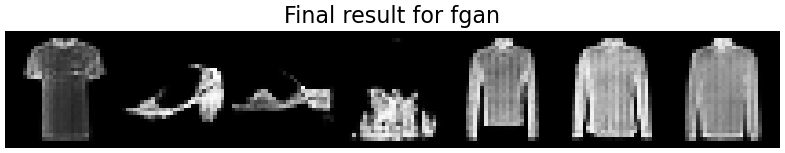

In [8]:
# ----------------------
# Run all three models
# ----------------------
data = FMData()
for kind in ['dcgan', 'wgan', 'fgan']:
    trainer = pl.Trainer(max_epochs=MAX_EPOCHS)
    model = GAN(kind, sample_dir=f'samples/{kind}')
    trainer.fit(model, data)

    img_file = f'samples/{kind}/epoch{MAX_EPOCHS-1}.png'
    img = Image.open(img_file)
    plt.figure(figsize=(10, 3))
    plt.imshow(np.array(img))
    plt.axis('off')
    plt.title(f'Final result for {kind}')
    plt.show()

### Justification

#### 1. Choice of f-divergence
We select the Pearson χ² divergence
$$D_{\chi^2}(p\|q) \;=\;\mathbb{E}_{x\sim q}\bigl[(\frac{p(x)}{q(x)} - 1)^2\bigr],$$
which in the f-GAN framework corresponds to
$$f(u) = (u - 1)^2,\quad u = \frac{p(x)}{q(x)}.$$
This choice is attractive because it yields a simple quadratic form and has been shown to balance mode coverage with sample quality in practice (Nowozin et al., 2016).

#### 2. Derivation via Fenchel conjugate
The convex conjugate of f is
$$f^*(t) = \sup_{u\ge0}\!\bigl\{\,t\,u - (u-1)^2\bigr\} = t + \frac{t^2}{4}.$$
In the f-GAN variational formulation one solves
$$\min_G \max_T\; \mathbb{E}_{x\sim p}\bigl[T(x)\bigr] - \mathbb{E}_{z\sim p(z)}\bigl[f^*(T(G(z)))\bigr].$$
Substituting $f^*(t)=t+\frac{t^2}{4}$ gives discriminator and generator losses
$$L_D = -\mathbb{E}_p[D(x)] + \mathbb{E}_z\!\Bigl[D(G(z)) + \frac{1}{4}D(G(z))^2\Bigr],$$
$$L_G = \mathbb{E}_z\!\Bigl[D(G(z)) + \frac{1}{4}D(G(z))^2\Bigr].$$

#### 3. Re-parameterization as Least Squares
Mao et al. (2017) showed that by shifting and scaling the critic's output one can rewrite these objectives exactly as mean-squared errors:
$$L_D = \tfrac{1}{2}\,\mathbb{E}\bigl[(D(x)-1)^2\bigr] + \tfrac{1}{2}\,\mathbb{E}\bigl[D(G(z))^2\bigr],$$
$$L_G = \tfrac{1}{2}\,\mathbb{E}\bigl[(D(G(z))-1)^2\bigr].$$
This yields a fully non-negative, stable loss with no need for Sigmoid activations or gradient clamping, yet remains mathematically equivalent to minimizing the Pearson χ² divergence.

#### 4. Practical benefits
- Stability: MSE losses avoid vanishing or exploding gradients.
- Simplicity: implementable with nn.MSELoss() and a linear–output discriminator.
- Empirical performance: widely used in LSGANs and shown to produce high-quality images on MNIST/Fashion-MNIST benchmarks (Mao et al., 2017).

———

### References:
- Nowozin, S., Cseke, B., & Tomioka, R. (2016). f-GAN: Training Generative Neural Samplers using Variational Divergence Minimization.
- Mao, X., Li, Q., Xie, H., Lau, R. Y., Wang, Z., & Paul Smolley, S. (2017). Least Squares Generative Adversarial Networks. ICCV.

## Problem 6. Trasformers

---

In [30]:
EPOCHS = 100
SEQ_SIZE = 5
EMBEDDING_DIM = 2
HIDDEN_DIM = 10

test_sentence = """thoma edison is wide known as one of histori most consequenti inventor a legaci born of both hi indisput
geniu in the laboratori and note ruthless as a businessman; the old adag is that histori is written by the victor
and in edison case he spun hi narr in real time sometim as in the case of invent develop by contemporari such
as nikola tesla that meant bend the truth a littl bit born in 1847 at the veri end of the industri revolut edison wa
part of a new wave of scientist and inventor that lit the way into the modern era hi fame research lab in menlo
park new jersey host the develop of innov that still undergird much of our industri and consum infrastructur
includ the phonograph (which record and play sound) motion pictur and the light bulb hi work there wa so
import that the town in which menlo park wa locat now bear hi name obsess with hi work and known to be an
exact boss edison had an ego as incandesc as hi light bulb a sens of hi own great that wa undoubtedli justiﬁ
he wa also incred competit will to do whatev wa requir to ensur that hi idea won out born in serbia tesla wa
a differ kind of geniu wherea edison wa an etern experiment and tinker tesla wa a human calcul and hi abil
to work out complex math and physic equat in hi mind help him achiev earli career success in europ after a
nomad adolesc spent travel and take class across eastern europ tesla wound up in hungari at the age of 25 hire
to work as an electr engin at the budapest telephon exchang he excel there channel the workahol tendenc he’d
display as a top student back in croatia befor drop out of school within a year he wa off to pari to work for
the continent edison compani an offshoot of the inventor success american busi at that point electr wa begin to
light up the street of citi around the world at ﬁrst most citi were use high voltag arc lamp to illumin the night 
sky but while they shone bright and amaz a civil that had throughout all of histori been govern by the sun rise
and fall the earli light technolog also present a problem: it wa veri danger arc light wa fuel by power station
that pump through more than 3000 volt of electr at a time which often led to spark overh and full on explos in
public place rain ﬂicker of electr down on pedestrian and start ﬁre with regular electr gener by direct current
(dc) wa a far safer altern and onc edison develop a stabl and long last incandesc lightbulb he set out to provid
light to home and build around the world by 1882 hi edison illumin compani open the world ﬁrst central power
station on pearl street in manhattan the compani use direct current to deliv 110 volt of electr to nearbi build it
start out with 59 custom and provid a signiﬁcantli reduc risk of accident mishap for the next two year edison dc
electr gener spread the incandesc light to a grow number of citi across the countri but for it grow reach it had
a signiﬁc weakness: electr deliv by direct current could onli travel so far especi in those earli day as a result
other inventor continu to develop what wa call altern current ac which could easili modul voltag use transform
tesla wa one of those ac devote in 1882 while work for edison parisian outpost and out on a walk with a friend
tesla wa suddenli struck with the solut to an engin challeng that had been vex him for some time hi abil to
visual entir complex mathemat equat and feat of engin came in handi as tesla dream up the mechan of an ac
gener motor develop and hone the altern current gener becam someth of an obsess for him and in 1884 when
hi american boss in pari wa summon back to the unit state he suggest that tesla emigr to the west and so in
septemb of that year tesla arriv in manhattan after a harrow journey in which most of hi possess were stolen
dure a mutini on the ship howev money wouldn’t be a concern for all that long tesla ran into edison himself
who invit the immigr inventor to work for him at the edison machin work on the lower east side of manhattan
a letter of recommend from hi old boss did not hurt hi caus at the time tesla recal in an interview year later he
wa in awe of hi new boss “thi wonder man who had receiv no scientif train yet had accomplish so much ﬁll me
with amazement" tesla wa put to work on a varieti of project includ repair the circuitri system on the oregon
the ﬁrst boat to be lit by electr power reassembl dc gener and other task year later in an interview conduct in
1921 tesla recal impress edison with hi quick ﬁx of the oregon light system to the point that edison declar him a
“damn good man” the serbian inventor wa also charg with creat an arc light system but hi usag of ac power wa
of no interest to edison who had a fortun invest in dc power and did not want to lose hi loyalti later tesla would
purportedli say that edison himself promis a larg sum to improv on the dc system then retract the offer when
tesla present him with hi work claim that he “did not understand american humor” infuri tesla to the point that
he storm out and set out on hi own determin to spite the elder inventor tesla onli work for edison for about six
month and after a time spent dig grave he receiv enough investor cash to set up hi own compani in rahway new
jersey close to menlo park those investor took the compani out from under him and it wasn’t until 1887 with a
new factori in manhattan that tesla wa abl to truli pursu hi ac motor it wouldn’t take long befor he’d master the
machin as he wa award seven separ patent for it variou mechan in the spring of 1888 soon after he licens those
patent to georg westinghous edison chief rival in the race to suppli citi with power the race between ac and dc
would escal from there with edison pull out nearli all the stop to prove that ac wa danger (though the fame death
by electrocut of topsi the eleph wa not hi doing) to discredit what would ultim prove a far superior system tesla
die nearli penniless though that had noth to do with edison he made a fortun from hi contract with westinghous
but lost it all through poor busi deal bad invest and expenditur on grand experi that result in failur hi suppos
rivalri with edison wa almost by associ and differ of opinion on scientif matter highlight onli in hindsight as
tesla incred career which span far more than ac power innov
""".lower().split()

# Build a list of ngrams.  

ngrams = [(test_sentence[i:i+SEQ_SIZE], test_sentence[i+SEQ_SIZE])
  for i in range(len(test_sentence) - SEQ_SIZE)]

# print the first 3, just so you can see what they look like
print(ngrams[:3])

vocab = list(set(test_sentence))
word_to_ix2 = {word: i for i, word in enumerate(vocab)}

[(['thoma', 'edison', 'is', 'wide', 'known'], 'as'), (['edison', 'is', 'wide', 'known', 'as'], 'one'), (['is', 'wide', 'known', 'as', 'one'], 'of')]


Adapted from the following link:
https://colab.research.google.com/drive/14jKgK1lE92oed7j3aZQ9-3dBWlwAUmDk?usp=sharing
Rewrapped the code with pytorch lightning.

In [31]:
learning_rate = 0.004

class Attention(nn.Module):
    """
    A custom self attention layer
    """
    def __init__(self, in_feat, out_feat):
        super().__init__()             
        self.Q = nn.Linear(in_feat, out_feat) # Query
        self.K = nn.Linear(in_feat, out_feat) # Key
        self.V = nn.Linear(in_feat, out_feat) # Value
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        Q = self.Q(x)
        K = self.K(x)
        V = self.V(x)
        d = K.size(-1)           # <-- correct "key" dimension
        # transpose the *last* two dims, not the first two
        QK_d = torch.matmul(Q, K.transpose(-2, -1)) / d**0.5
        prob = self.softmax(QK_d)
        attention = prob @ V
        return attention

class Model(pl.LightningModule):
    def __init__(
        self, vocab_size, embed_size, seq_size, hidden, mode='attn'
    ):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.layer = Attention(embed_size, hidden) \
            if mode == 'attn' else nn.Linear(embed_size, hidden)
        self.fc1 = nn.Linear(hidden*seq_size, vocab_size)
        self.learning_rate = learning_rate
        self.save_hyperparameters()
        
    def forward(self, x):
        x = self.embed(x)
        x = self.layer(x).view(x.size(0), -1)
        x = self.fc1(x)
        return F.log_softmax(x, dim=1)
    
    def training_step(self, batch, batch_idx):
        context, target = batch
        log_probs = self(context)
        target = target.view(-1) # Reshape target to be 1D tensor
        loss = F.nll_loss(log_probs, target)
        self.log('train_loss', loss, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)

dataset = [(torch.tensor([word_to_ix2[w] for w in context], dtype=torch.long),
            torch.tensor([word_to_ix2[target]], dtype=torch.long))
           for context, target in ngrams]
train_loader = torch.utils.data.DataLoader(
    dataset, batch_size=1, num_workers=7, persistent_workers=True
)

def train_with_mode(mode):
    model = Model(len(vocab), EMBEDDING_DIM, SEQ_SIZE, HIDDEN_DIM, mode=mode)
    trainer = pl.Trainer(max_epochs=EPOCHS)
    trainer.fit(model, train_loader)
    torch.cuda.empty_cache()
    return model

model_attn = train_with_mode('attn')
model_linr = train_with_mode('linr')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | embed | Embedding | 1.0 K  | train
1 | layer | Attention | 90     | train
2 | fc1   | Linear    | 25.7 K | train
--------------------------------------------
26.7 K    Trainable params
0         Non-trainable params
26.7 K    Total params
0.107     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | embed | Embedding | 1.0 K  | train
1 | layer | Linear    | 30     | train
2 | fc1   | Linear    | 25.7 K | train
--------------------------------------------
26.7 K    Trainable params
0         Non-trainable params
26.7 K    Total params
0.107     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


	Attention Model:
Word         | Tesla Distance  |         Edison Distance | Closer to 
------------------------------------------------------------
incandesc    |           2.525 |                   2.433 | Edison    
electr       |           1.476 |                   1.345 | Edison    
inventor     |           2.116 |                   0.892 | Edison    
gener        |           2.802 |                   2.813 | Tesla     
develop      |           2.568 |                   0.263 | Edison    
light        |           2.503 |                   0.337 | Edison    
scientif     |           3.147 |                   0.471 | Edison    
motor        |           3.157 |                   3.816 | Tesla     
altern       |           0.527 |                   3.243 | Tesla     
	Linear Model:
Word         | Tesla Distance  |         Edison Distance | Closer to 
------------------------------------------------------------
incandesc    |           0.299 |                   1.615 | Tesla     
elect

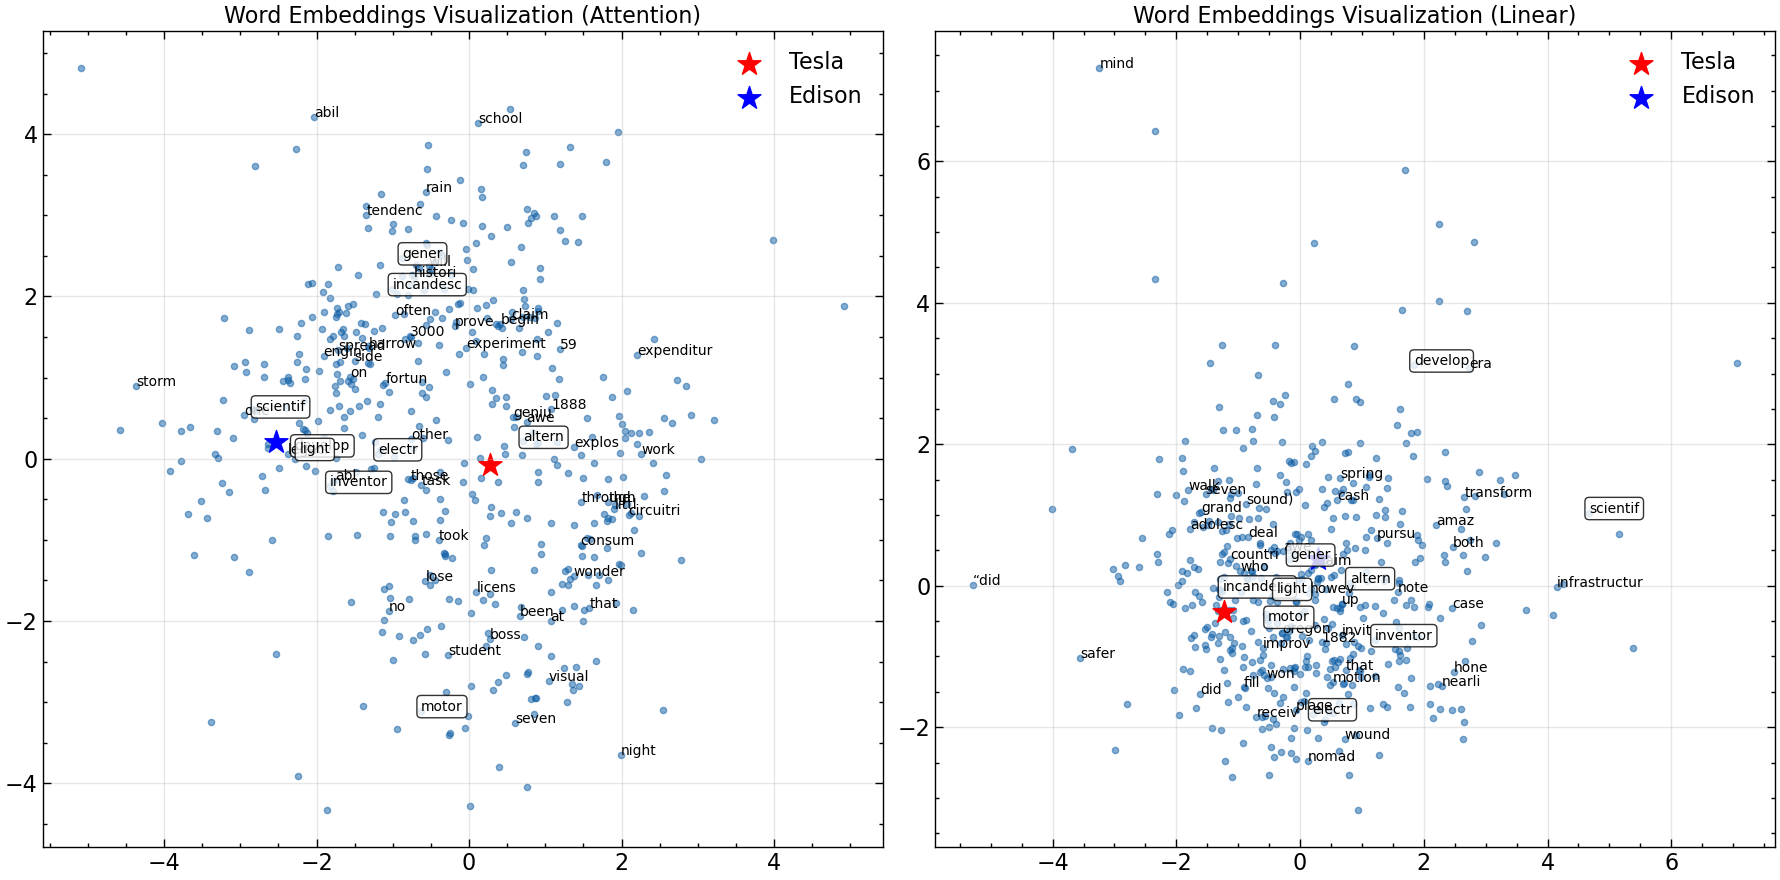

In [32]:
# ix_to_word = {ix: w for w, ix in word_to_ix2.items()}

# Words to compare, assume in vocab
stems = [
    'incandesc',    # E
    'electr',       # D
    'inventor',     # B
    'gener',        
    'develop',      # C
    'light',        # G
    'scientif',     # A
    'motor',        # F
    'altern'        # F
]

def print_distances(embeddings):
    tesla_vec = embeddings[word_to_ix2['tesla']]
    edison_vec = embeddings[word_to_ix2['edison']]
    print(f"{'Word':12s} | {'Tesla Distance':15s} | \
        {'Edison Distance':15s} | {'Closer to':10s}")
    print("-" * 60)
    for stem in stems:
        vec = embeddings[word_to_ix2[stem]]
        d_tesla = np.linalg.norm(vec - tesla_vec)
        d_edison = np.linalg.norm(vec - edison_vec)
        closer = 'Tesla' if d_tesla < d_edison else 'Edison'
        print(f"{stem:12s} | {d_tesla:15.3f} | \
            {d_edison:11.3f} | {closer:10s}")

def plot_embeddings(embeddings, ax, mode):
    ax.scatter(embeddings[:, 0], embeddings[:, 1], alpha=0.5, s=20)
    for i, word in enumerate(vocab):
        if word not in stems + ['tesla', 'edison']:
            # roll a dice and anoote
            if np.random.rand() < 0.088:
                ax.annotate(word, (embeddings[i, 0], embeddings[i, 1]))
        if word in stems: # Annotate only important words
            ax.annotate(word, (embeddings[i, 0], embeddings[i, 1]),
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    tesla_idx, edison_idx = word_to_ix2['tesla'], word_to_ix2['edison']
    ax.scatter(embeddings[tesla_idx, 0], embeddings[tesla_idx, 1], \
        s=300, marker='*', color='red', label='Tesla')
    ax.scatter(embeddings[edison_idx, 0], embeddings[edison_idx, 1], \
        s=300, marker='*', color='blue', label='Edison')
    ax.set_title(f'Word Embeddings Visualization ({mode})')
    ax.legend()
    ax.grid(alpha=0.3)

fig, ax = plt.subplots(1, 2, figsize=(18, 9))

print("\tAttention Model:")
model = model_attn; model.eval()
embeddings = model.embed.weight.detach().cpu().numpy()
print_distances(embeddings)
plot_embeddings(embeddings, ax[0], 'Attention')

print("\tLinear Model:")
model = model_linr; model.eval()
embeddings = model.embed.weight.detach().cpu().numpy()
print_distances(embeddings)
plot_embeddings(embeddings, ax[1], 'Linear')

plt.tight_layout()
plt.show()

### Observations

#### 0 · Procedure

> 	1.	Used 9 stems from corpus: incandesc, electr, inventor, gener, develop, light, scientif, motor, altern.
> 	2.	Compared two models: Attention (embedding→self-attention→classifier) vs Linear (embedding→linear→classifier).
> 	3.	Measured distances between stem embeddings and Tesla/Edison embeddings to determine conceptual proximity.
> 	4.	For two-stem questions: person wins if both stems favor them; tie if stems split.

⸻

#### 1 & 2 · Answers A – F

| Q | Conceptual stems | Transformer result | Linear result |
|---|------------------|-------------------|---------------|
| A More scientific? | scientif | Edison | Edison |
| B Better inventor? | inventor | Edison | Edison |
| C Better developer? | develop | Edison | Edison |
| D Researched electricity? | electr, gener | Edison (stems split 1-1 but electr dominates) | Tie (each wins one stem) |
| E Worked on incandescent light? | incandesc, light | Edison (both stems) | Tie (incandesc→Tesla, light→Edison) |
| F Worked on AC-motor design? | motor, altern | Tesla (wins both) | Tie (motor→Tesla, altern→Edison) |

⸻

#### 2 · Discussion & insight

- Unchanged conclusions (A-C). 
- Electricity (D). In the attention model, electr (the strongest cue) anchors to Edison, giving him the edge even though gener drifts slightly toward Tesla.  The linear model splits evenly—showing that architectural choice can erase a weak majority signal.
- Incandescent light (E). Attention keeps both incandesc and light near Edison (historically correct).  The linear projection pulls the rarer word incandesc toward Tesla, creating a tie.
- AC-motor design (F). Self-attention preserves the Tesla-alternating-current link (motor, altern both near Tesla).  With a single linear layer, altern swings across the space toward Edison, wiping out Tesla's clear win.
- Why the differences? Self-attention lets each token build its own context, so niche associations survive.  A global linear projection averages every window identically; rare Tesla-specific contexts get washed out, and the embedding cloud contracts around the more frequently mentioned Edison.

⸻

#### 3 · Visual check

- Visual check. Scatter-plots confirm this: the attention map is sparser, with altern and motor in Tesla's quadrant; the linear map is tighter and shifts those same tokens toward Edison or the origin.

> **Bottom line:** Even on a toy corpus, architectural choices can flip qualitative historical inferences.  Self-attention safeguarded Tesla's association with alternating-current motors, whereas a plain linear encoder amplified the dominant Edison narrative.

## Problem 7. Shaply Values

---

Here's the full table of all 6 orders (permutations) and the marginal contributions of players 1, 2 and 3 in each:

| Order | Player 1's contrib. | Player 2's contrib. | Player 3's contrib. |
|-------|---------------------|---------------------|---------------------|
| 123   | v({1}) = 100        | v({1,2})–v({1}) = 270–100 = 170 | v({1,2,3})–v({1,2}) = 500–270 = 230 |
| 132   | v({1}) = 100        | v({1,2,3})–v({1,3}) = 500–375 = 125 | v({1,3})–v({1}) = 375–100 = 275 |
| 213   | v({1,2})–v({2}) = 270–125 = 145 | v({2}) = 125 | v({1,2,3})–v({1,2}) = 500–270 = 230 |
| 231   | v({1,2,3})–v({2,3}) = 500–350 = 150 | v({2}) = 125 | v({2,3})–v({2}) = 350–125 = 225 |
| 312   | v({1,3})–v({3}) = 375–50 = 325 | v({1,2,3})–v({1,3}) = 500–375 = 125 | v({3}) = 50 |
| 321   | v({1,2,3})–v({2,3}) = 500–350 = 150 | v({2,3})–v({3}) = 350–50 = 300 | v({3}) = 50 |

⸻

Shapley values are just the average of each player's contributions across all 6 orders:

$$
\begin{aligned}
x_1 &= \frac{100 + 100 + 145 + 150 + 325 + 150}{6}
= \frac{970}{6}\approx 161.67,\\
x_2 &= \frac{170 + 125 + 125 + 125 + 125 + 300}{6}
= \frac{970}{6}\approx 161.67,\\
x_3 &= \frac{230 + 275 + 230 + 225 + 50 + 50}{6}
= \frac{1060}{6}\approx 176.67.
\end{aligned}
$$

Finally, note that in every ordering the three marginal contributions sum to
$v(1,2,3)=500$,
and hence the sum of the Shapley values also equals 500. So the total allocated $x_1+x_2+x_3$ is equal to the value of the grand coalition. This also holds by adding up $x_1,x_2,x_3$ directly.

## Problem 8. RealNVP

---

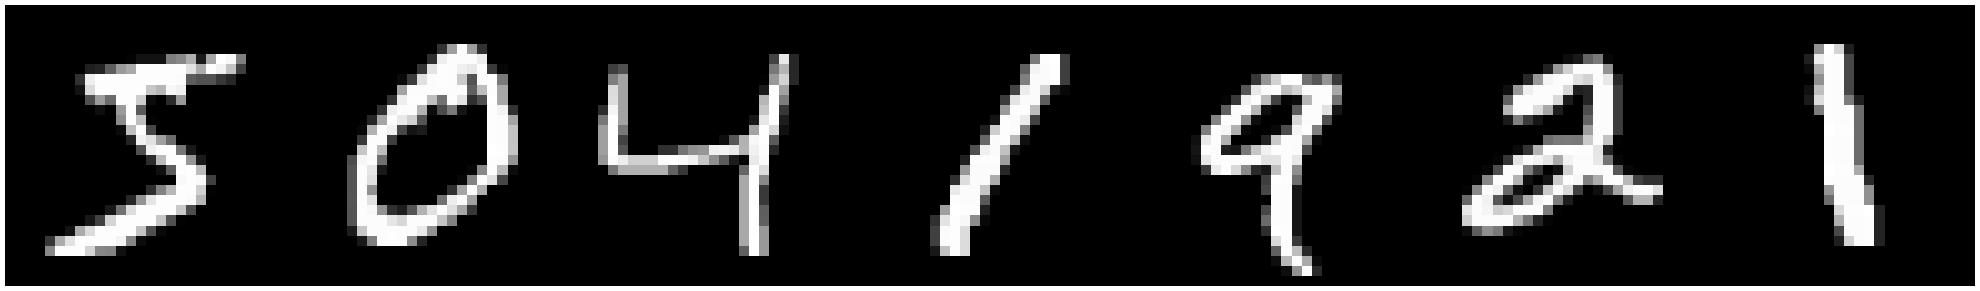

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type       | Params | Mode 
----------------------------------------------------
0 | t            | ModuleList | 14.9 M | train
1 | s            | ModuleList | 14.9 M | train
  | other params | n/a        | 6.3 K  | n/a  
----------------------------------------------------
29.7 M    Trainable params
6.3 K     Non-trainable params
29.7 M    Total params
118.975   Total estimated model params size (MB)
138       Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


In [143]:
class RealNVP(pl.LightningModule):
    def __init__(self, nets, nett, mask, prior):
        super(RealNVP, self).__init__()
        self.prior = prior
        self.mask = nn.Parameter(mask, requires_grad=False)
        self.t = torch.nn.ModuleList([nett() for _ in range(len(masks))])
        self.s = torch.nn.ModuleList([nets() for _ in range(len(masks))])

    def g(self, z):
        x = z
        for i in range(len(self.t)):
            x_ = x*self.mask[i]
            s = self.s[i](x_)*(1 - self.mask[i])
            t = self.t[i](x_)*(1 - self.mask[i])
            x = x_ + (1 - self.mask[i]) * (x * torch.exp(s) + t)
        return x

    def f(self, x):
        log_det_J, z = x.new_zeros(x.shape[0]), x
        for i in reversed(range(len(self.t))):
            z_ = self.mask[i] * z
            s = self.s[i](z_) * (1-self.mask[i])
            t = self.t[i](z_) * (1-self.mask[i])
            z = (1 - self.mask[i]) * (z - t) * torch.exp(-s) + z_
            log_det_J -= s.sum(dim=1)
        return z, log_det_J

    def log_prob(self,x):
        z, logp = self.f(x)
        return self.prior.log_prob(z) + logp

    def sample(self, batchSize):
        z = self.prior.sample((batchSize, 1))
        logp = self.prior.log_prob(z)
        x = self.g(z)
        return x
    
    def training_step(self, batch, batch_idx):
        x, _ = batch
        B = x.shape[0]
        x = x.view(B, -1)
        loss = -self.log_prob(x).mean()
        self.log('train_loss', loss, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam([p for p in self.parameters() \
            if p.requires_grad==True], lr=1e-4)

α = 1e-6
transform = transforms.Compose([
    transforms.ToTensor(),
    # # dequantize
    # transforms.Lambda(lambda x: x + torch.rand_like(x) / 256.0),
    # # logit transform
    # transforms.Lambda(lambda x: torch.log(α + (1-2*α)*x) - torch.log(1-α-(1-2*α)*x)),
])
train_set = datasets.MNIST(root='./data', train=True, download=True, \
    transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=100, \
    shuffle=True, num_workers=7, persistent_workers=True)

samples = [train_set[i][0] for i in range(7)]
grid = make_grid(samples, nrow=7, padding=0, normalize=True)
plt.figure(figsize=(20, 20))
plt.imshow(grid.permute(1, 2, 0).cpu(), cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

input_dim = 28 * 28
hidden_dim = 648
nets = lambda: nn.Sequential(
    nn.Linear(input_dim, hidden_dim), nn.LeakyReLU(), 
    nn.Linear(hidden_dim, hidden_dim), nn.LeakyReLU(), 
    nn.Linear(hidden_dim, hidden_dim), nn.LeakyReLU(), 
    nn.Linear(hidden_dim, input_dim), nn.Tanh())
nett = lambda: nn.Sequential(
    nn.Linear(input_dim, hidden_dim), nn.LeakyReLU(), 
    nn.Linear(hidden_dim, hidden_dim), nn.LeakyReLU(),
    nn.Linear(hidden_dim, hidden_dim), nn.LeakyReLU(),
    nn.Linear(hidden_dim, input_dim))
masks = torch.zeros((8, input_dim))
for i in range(8):
    if i % 2 == 0:
        masks[i, ::2] = 1  # Set even indices to 1 in even-indexed masks
    else:
        masks[i, 1::2] = 1  # Set odd indices to 1 in odd-indexed masks
prior = torch.distributions.MultivariateNormal(torch.zeros(input_dim), torch.eye(input_dim))

flow = RealNVP(nets, nett, masks, prior)
trainer = pl.Trainer(max_epochs=20, accelerator='cpu')
trainer.fit(flow, train_loader)

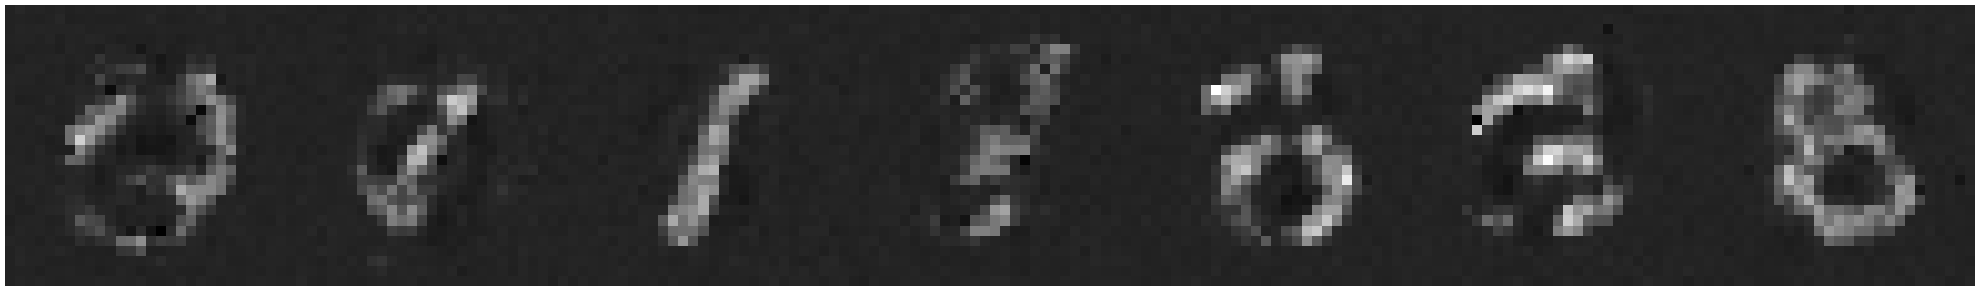

In [176]:
flow.eval()
with torch.no_grad():
    samples = flow.sample(7).view(7, 1, 28, 28)
    grid = make_grid(samples, nrow=7, padding=0, normalize=True)
    plt.figure(figsize=(20, 20))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## Problem 9. 

---

1. Match to the general Gaussian conditioning identity

We know for
$p(x)=\mathcal{N}(x\mid \mu,\;\Lambda^{-1})$, $p(y\mid x)=\mathcal{N}(y\mid A x + b,\;L^{-1})$,
the posterior is
$$
p(x\mid y)
=\mathcal{N}\bigl(x\mid \underbrace{\Sigma\,(A^T\,L\,(y-b)\;+\;\Lambda\,\mu)}_{\text{mean}},\;\Sigma\bigr),
\quad
\Sigma=(\Lambda + A^T\,L\,A)^{-1}.
$$

In our diffusion setting we set
$$
\begin{aligned}
&\underbrace{x}{x}\;\longleftrightarrow\;x_{t-1},
\quad
\underbrace{y}{y}\;\longleftrightarrow\;x_t,
\\
&q(x_{t-1}\mid x_0)
=\mathcal{N}\bigl(x_{t-1}\mid \mu,\;\Lambda^{-1}\bigr)
\quad\text{with}\quad
\mu=\sqrt{\bar\alpha_{t-1}}\,x_0,
\;\;\Lambda=\frac1{\,1-\bar\alpha_{t-1}\,}\,I,
\\
&q(x_t\mid x_{t-1})
=\mathcal{N}\bigl(x_t\mid A\,x_{t-1}+b,\;L^{-1}\bigr)
\quad\text{with}\quad
A=\sqrt{\alpha_t}\,I,\;
b=0,\;
L=\frac1{\,1-\alpha_t\,}\,I.
\end{aligned}
$$

⸻

2. Compute the posterior precision matrix

We need
$\Lambda + A^T\,L\,A
=\frac1{1-\bar\alpha_{t-1}}\,I
\;+\;\bigl(\sqrt{\alpha_t}\,I\bigr)^T
\,\frac1{1-\alpha_t}\,I
\,\bigl(\sqrt{\alpha_t}\,I\bigr)$.
Since $A=\sqrt{\alpha_t}I$ commutes with everything,
$A^T\,L\,A
=\frac{\alpha_t}{1-\alpha_t}\,I$.
Thus
$\Lambda + A^T L A
=\Bigl(\frac1{1-\bar\alpha_{t-1}} + \frac{\alpha_t}{1-\alpha_t}\Bigr)\,I$.
Put over a common denominator $(1-\bar\alpha_{t-1})(1-\alpha_t)$:
$\frac{1-\alpha_t + \alpha_t(1-\bar\alpha_{t-1})}{(1-\bar\alpha_{t-1})(1-\alpha_t)}
=\frac{1 - \bar\alpha_{t-1}\,\alpha_t - \alpha_t + \alpha_t}{(1-\bar\alpha_{t-1})(1-\alpha_t)}
=\frac{1-\bar\alpha_t}{(1-\bar\alpha_{t-1})(1-\alpha_t)}$.
Hence the precision is
$(\Lambda + A^TLA)
=\frac{1-\bar\alpha_t}{(1-\bar\alpha_{t-1})(1-\alpha_t)}\,I$,
and the covariance is its inverse,
$\Sigma
=\Bigl(\Lambda + A^TLA\Bigr)^{-1}
=\frac{(1-\bar\alpha_{t-1})(1-\alpha_t)}{1-\bar\alpha_t}\;I$.

⸻

3. Compute the posterior mean vector

The mean is
$m \;=\;\Sigma\bigl(A^T\,L\,(x_t - b)\;+\;\Lambda\,\mu\bigr)$.
Compute each term:
1. Likelihood term
$A^T\,L\,(x_t - b)
=(\sqrt{\alpha_t}I)^T\;\frac1{1-\alpha_t}I\;(x_t - 0)
=\frac{\sqrt{\alpha_t}}{1-\alpha_t}\;x_t$.
2. Prior term
$\Lambda\,\mu
=\frac1{1-\bar\alpha_{t-1}}\,I\;\bigl(\sqrt{\bar\alpha_{t-1}}\,x_0\bigr)
=\frac{\sqrt{\bar\alpha_{t-1}}}{1-\bar\alpha_{t-1}}\;x_0$.

So
$m
=\Sigma\Bigl(\frac{\sqrt{\alpha_t}}{1-\alpha_t}\,x_t
+\frac{\sqrt{\bar\alpha_{t-1}}}{1-\bar\alpha_{t-1}}\,x_0\Bigr)$.
Now multiply by $\Sigma=\frac{(1-\bar\alpha_{t-1})(1-\alpha_t)}{1-\bar\alpha_t}I$, distributing:
- Coefficient of $x_t$:
$\frac{(1-\bar\alpha_{t-1})(1-\alpha_t)}{1-\bar\alpha_t}
\;\times\;
\frac{\sqrt{\alpha_t}}{1-\alpha_t}
=\frac{\sqrt{\alpha_t}\,(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}$.
- Coefficient of $x_0$:
$\frac{(1-\bar\alpha_{t-1})(1-\alpha_t)}{1-\bar\alpha_t}
\;\times\;
\frac{\sqrt{\bar\alpha_{t-1}}}{1-\bar\alpha_{t-1}}
=\frac{\sqrt{\bar\alpha_{t-1}}\,(1-\alpha_t)}{1-\bar\alpha_t}$.

Putting these together,
$m
=\frac{\sqrt{\alpha_t}\,(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}\,x_t
\;+\;
\frac{\sqrt{\bar\alpha_{t-1}}\,(1-\alpha_t)}{1-\bar\alpha_t}\,x_0$.

⸻

4. Final form

Thus the conditional
$$
q(x_{t-1}\mid x_t,x_0)
=\mathcal{N}\!\Bigl(x_{t-1}\;\Bigm|\;m,\;\Sigma\Bigr)
$$
with
$$
\boxed{
\begin{aligned}
m &= \frac{\sqrt{\alpha_t}\,(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}\;x_t
\;+\;\frac{\sqrt{\bar\alpha_{t-1}}\,(1-\alpha_t)}{1-\bar\alpha_t}\;x_0,
\\
\Sigma &= \frac{(1-\alpha_t)\,(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}\;I,
\end{aligned}
}
$$
which is exactly the stated result.

## Problem 10. 

---


1. Network definition & initialization

Consider a fully‐connected network of depth $L$.  For layer $\ell$, the pre‐activation of neuron $i$ on input $x$ is
$$z_i^\ell(x)
\;=\;
b_i^\ell
\;+\;
\sum_{j=1}^{N_{\ell-1}}
W_{ij}^\ell\;\phi\bigl(z_j^{\ell-1}(x)\bigr),$$
where
- $\phi$ is some nonlinearity (e.g.\ ReLU, tanh, …),
- $W_{ij}^\ell\overset{\rm i.i.d.}{\sim} \mathcal{N}(0,\;\frac{\sigma_w^2}{N_{\ell-1}})$,
- $b_i^\ell\overset{\rm i.i.d.}{\sim}\mathcal{N}(0,\;\sigma_b^2)$,
- and $z_j^0(x)$ is the $j$-th coordinate of the input $x$.

We will send each layer width $N_{\ell}\to\infty$ in turn.  By the Central Limit Theorem (and since each neuron aggregates many small i.i.d.\ contributions), for any fixed pair of inputs $x,x'$, the pair $\bigl(z_i^\ell(x),\,z_i^\ell(x')\bigr)$ converges to a zero‐mean bivariate Gaussian whose covariance we denote
$$K^\ell(x,x') \;=\;\mathbb{E}\bigl[z_i^\ell(x)\,z_i^\ell(x')\bigr].$$

⸻

2. Mean and covariance of the next‐layer pre-activations

Fix layer $\ell$ and drop the superscript for clarity.  For one neuron $i$,
1. Bias term
$\displaystyle\mathbb{E}[b_i^2]=\sigma_b^2$, and $b_i$ is independent of everything else, so
$$\mathrm{Cov}\bigl(b_i,b_i\bigr)
\;=\;\sigma_b^2.$$
2. Weight‐sum term
$$S \;=\;\sum_{j=1}^{N_{\ell-1}} W_{ij}\;\phi\bigl(z_j^{\mathrm{prev}}(x)\bigr),
\quad
S' \;=\;\sum_{j=1}^{N_{\ell-1}} W_{ij}\;\phi\bigl(z_j^{\mathrm{prev}}(x')\bigr).$$
Since the $W_{ij}$ are zero‐mean and independent of the $z_j^{\mathrm{prev}}$, and
$$\mathbb{E}\bigl[W_{ij}W_{ik}\bigr]
=\frac{\sigma_w^2}{N_{\ell-1}}\;\delta_{jk},$$
the cross‐covariance is
$$\mathrm{Cov}(S,S')
=\sum_{j,k}
\mathbb{E}[W_{ij}W_{ik}]\;
\mathbb{E}\bigl[\phi(z_j^{\mathrm{prev}}(x))\,\phi(z_k^{\mathrm{prev}}(x'))\bigr]
=\frac{\sigma_w^2}{N_{\ell-1}}
\sum_{j=1}^{N_{\ell-1}}
\mathbb{E}\bigl[\phi(z_j^{\mathrm{prev}}(x))\,\phi(z_j^{\mathrm{prev}}(x'))\bigr].$$
But as $N_{\ell-1}\to\infty$, by the law of large numbers the empirical average
$$\frac1{N_{\ell-1}}\sum_j\phi(z_j(x))\phi(z_j(x'))$$
converges to the expectation under the previous-layer GP:
$$
\mathbb{E}_{\,z\sim\mathcal{GP}(0,K^{\ell-1})}\!\bigl[\phi\!\bigl(z(x)\bigr)\,\phi\!\bigl(z(x')\bigr)\bigr].
$$

Putting bias and weight‐sum together,
$$
K^\ell(x,x')
\;=\;
\underbrace{\sigma_b^2}_{\text{bias}}
\;+\;
\underbrace{\sigma_w^2}_{\text{weight scale}}
\;\mathbb{E}_{z\sim\mathcal{GP}(0,K^{\ell-1})}\!\Bigl[\phi\bigl(z(x)\bigr)\,\phi\bigl(z(x')\bigr)\Bigr].
$$

That is the first claimed formula:
$$
\boxed{
K^\ell(x,x')
=\sigma_b^2
\;+\;
\sigma_w^2\,
\mathbb{E}_{z_i^{\,\ell-1}\sim\mathcal{GP}(0,K^{\ell-1})}
\bigl[\phi\bigl(z_i^{\ell-1}(x)\bigr)\,\phi\bigl(z_i^{\ell-1}(x')\bigr)\bigr].
}
$$

⸻

3. Why the inductive form

Notice that for a bivariate Gaussian $(u,v)\sim\mathcal{N}(0,\Sigma)$
with
$$\Sigma=\begin{pmatrix}K^{\ell-1}(x,x)&K^{\ell-1}(x,x')\\K^{\ell-1}(x',x)&K^{\ell-1}(x',x')\end{pmatrix},$$
the scalar expectation
$$\mathbb{E}\bigl[\phi(u)\,\phi(v)\bigr]$$
depends only on the three entries
$\bigl(K^{\ell-1}(x,x'),\,K^{\ell-1}(x,x),\,K^{\ell-1}(x',x')\bigr)$.  We may therefore introduce the function
$$F_\phi\bigl(K^{\ell-1}(x,x'),\,K^{\ell-1}(x,x),\,K^{\ell-1}(x',x')\bigr)
\;=\;
\mathbb{E}_{(u,v)\sim\mathcal{N}(0,\Sigma)}
\bigl[\phi(u)\,\phi(v)\bigr].$$
Plugging this back into our recursion gives the clean inductive form
$$\boxed{
K^\ell(x,x')
=\sigma_b^2
\;+\;
\sigma_w^2\,
F_\phi\!\bigl(
K^{\ell-1}(x,x'),\;
K^{\ell-1}(x,x),\;
K^{\ell-1}(x',x')
\bigr).
}$$
In words: to get the level-$\ell$ kernel, you take a bias term plus the weight scale times a fixed scalar function of the previous-layer covariances.

⸻

Summary
1. Gaussianity of each neuron's pre-activations comes from CLT in the infinite-width limit.
2. Bias contributes $\sigma_b^2$.
3. Weight sum contributes $\sigma_w^2$ times the average $\phi(z)\phi(z')$ under the previous GP.
4. That average only depends on the 3 previous-layer kernel values $(K^{\ell-1}(x,x'),K^{\ell-1}(x,x),K^{\ell-1}(x',x'))$, yielding the inductive map $F_\phi$.

This completes the derivation of both the raw expectation form and its compressed inductive version.